# Final Report - Data Science

**Important**: this report may be written in either **Portuguese or English**. However, the selected language must be used consistently throughout the entire report. Mixing Portuguese and English is not allowed.

## Bachelor's Degree in Computer Science / PUCPR (2026-2)

**Prof. Rayson Laroca**

`Luiz Henrique Matoso` - `luiz.matoso@pucpr.edu.br`

# Import the libs you need

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your data

Below, load the data using pandas and perform all necessary data cleaning to ensure that the data types are correct for further analysis.

In [ ]:
df = pd.read_csv("../data/PhiUSIIL_Phishing_URL_Dataset.csv")

display(df.head())

print("Shape:", df.shape)

df.info()

display(df.describe())

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


Shape: (235795, 56)
<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  str    
 1   URL                         235795 non-null  str    
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  str    
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  str    
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasOb

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


In [ ]:
# Check for missing values
missing_values = df.isnull().sum().sum()
print(f"Missing values: {missing_values}")

# Check for duplicated rows
duplicated_rows = df.duplicated().sum()
print(f"Duplicated rows: {duplicated_rows}")

# The dataset documentation explicitly states that FILENAME can be ignored,
# since it is only an identifier and is not one of the predictive features.
df = df.drop(columns=["FILENAME"])

# Verify that the target contains only the expected binary classes:
# 0 = phishing and 1 = legitimate.
expected_labels = {0, 1}
actual_labels = set(df["label"].unique())

if actual_labels != expected_labels:
    raise ValueError(f"Unexpected label values found: {actual_labels}")

# Verify the resulting dataset structure
print(f"Shape after cleaning: {df.shape}")
print("\nData types:")
print(df.dtypes.value_counts())

Missing values: 0
Duplicated rows: 0
Shape after cleaning: (235795, 55)

Data types:
int64      41
float64    10
str         4
Name: count, dtype: int64


# Statistical Description

In [25]:
# Statistical description of the dataset

n_instances = df.shape[0]
n_columns = df.shape[1]
n_features = n_columns - 1  # excluding the target variable

print(f"Number of instances: {n_instances}")
print(f"Number of features: {n_features}")
print("Task: Binary classification")
print("Target variable: label")
print("Number of classes:", df["label"].nunique())

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nClass distribution (%):")
print(df["label"].value_counts(normalize=True).mul(100).round(2))

Number of instances: 235795
Number of features: 54
Task: Binary classification
Target variable: label
Number of classes: 2

Class distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Class distribution (%):
label
1    57.19
0    42.81
Name: proportion, dtype: float64


The dataset contains 235,795 instances and 54 predictive features after removing the `FILENAME` identifier. The task is a binary classification problem in which the target variable `label` indicates whether a webpage is phishing (`0`) or legitimate (`1`).

The two classes are relatively balanced, with approximately 42.81% phishing instances and 57.19% legitimate instances. Therefore, there is no severe class imbalance in the dataset.

# Univariate data analysis

For the univariate analysis, 20 features were selected to represent different aspects of the dataset, including URL structure, domain characteristics, textual composition, HTML content, and reference behavior.

The selected variables were chosen because they have interpretable meanings in the context of phishing detection and can later support meaningful multivariate analyses.

In [28]:
selected_features = [
    "URLLength",
    "DomainLength",
    "URLSimilarityIndex",
    "CharContinuationRate",
    "TLDLegitimateProb",
    "URLCharProb",
    "NoOfSubDomain",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS",
    "LineOfCode",
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "NoOfImage",
    "NoOfSelfRef",
    "NoOfExternalRef"
]

In [46]:
def analyze_numeric_feature(feature, limit_99=False):
    data = df[feature]

    print(f"Feature: {feature}")
    print(f"Mean: {data.mean():.4f}")
    print(f"Standard deviation: {data.std():.4f}")
    print(f"Skewness: {data.skew():.4f}")
    print(f"Kurtosis: {data.kurt():.4f}")
    print(f"Minimum: {data.min()}")
    print(f"Median: {data.median()}")
    print(f"Maximum: {data.max()}")

    plot_data = data
    title = f"Distribution of {feature}"

    if limit_99:
        upper_limit = data.quantile(0.99)
        print(f"99th percentile: {upper_limit}")

        plot_data = data[data <= upper_limit]
        title += " (up to 99th percentile)"

    plt.figure(figsize=(8, 4))
    plt.hist(plot_data, bins=50)
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

### 1. URL Length

`URLLength` represents the total number of characters in the URL.

This variable was selected because unusually long URLs may contain additional paths, parameters, subdomains, or encoded information, making URL length a potentially relevant characteristic when analyzing phishing websites.

Feature: URLLength
Mean: 34.5731
Standard deviation: 41.3142
Skewness: 53.3217
Kurtosis: 5914.0090
Minimum: 13
Median: 27.0
Maximum: 6097
99th percentile: 144.0


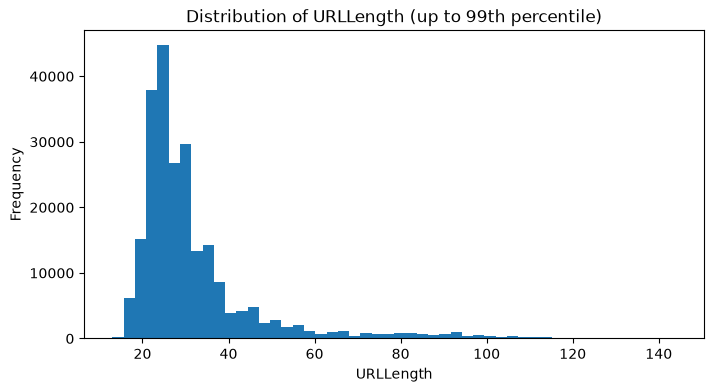

In [47]:
analyze_numeric_feature("URLLength", limit_99=True)

The distribution of `URLLength` is strongly right-skewed. Most URLs are relatively short, while a small number of observations contain exceptionally long URLs.

The mean URL length is approximately 34.57 characters, while the median is 27 characters. The higher mean is consistent with the strong positive skewness caused by unusually long URLs.

The standard deviation is approximately 41.31 characters, indicating considerable variability. The maximum URL length is 6,097 characters, which is substantially higher than the typical values and contributes to the extreme skewness and kurtosis.

For visualization purposes, the histogram was limited to the 99th percentile, corresponding to URLs with up to 144 characters. This restriction was applied only to the visualization; no observations were removed from the dataset or from the statistical calculations.

### 2. Domain Length

`DomainLength` represents the total number of characters in the domain name.

This variable was selected because domain length may reflect differences in naming patterns between legitimate and phishing websites. Unusually long domains can result from additional words, subdomains, or attempts to imitate legitimate services.

Feature: DomainLength
Mean: 21.4704
Standard deviation: 9.1508
Skewness: 2.5134
Kurtosis: 10.6602
Minimum: 4
Median: 20.0
Maximum: 110


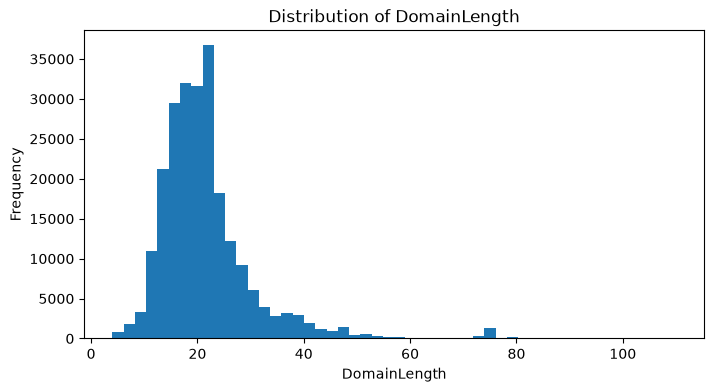

In [ ]:
analyze_numeric_feature("DomainLength")

# Multivariate data analysis

In this section, you should plot at least **5 multivariate visualizations**. The key here is to investigate underlying correlations and behaviors within the dataset.
Naturally, as visualizations are being created, we should end up with obvious results, yet, you should find at least **ONE** non-obvious behavior in the data.

Please follow these steps for creating your visualizations:
1. State an hypothesis. Explain why you have selected these specific variables and what you expect to discover through their relationship;
2. Determine what kind of visualization is the most suitable;
3. Report the findings and discuss whether they corroborate or not the aforementioned hypothesis.


**Hints**

In this section, make sure you go beyond naive explorations. For example, consider applying techniques such as PCA, t-SNE, or even others that we haven't covered in the lectures. The goal is to cultivate a critical mindset toward data analysis and our work.

**Important**

It is strictly prohibited to create multivariate visualizations using variables that were not included in the previous section (univariate data analysis).

In [21]:
# again, feel free to place as many cells to plot the visualizations,
# as well as describe to the main findings

# Final Plots (Effective Data Visualization)

In this section, you need to **enhance 3 multivariate visualizations** that were presented in the previous section of the report.
The goal is to enhance these visualizations so that they can be effectively presented to an audience unfamiliar with the dataset or with data analysis.
**Therefore, make sure that their size, colors, textures, and other visual elements are appropriate and convey the intended information to the audience.**

For your final plots, make sure you follow these steps:
1. Present the plot;
2. Provide a description of the visualization, highlighting the key findings that can be drawn from it.


**Hint**: take a look at the checklist based on Evergreen’s work to ensure your visualizations meet the best practices for clarity and impact.

In [22]:
# your code goes here

# Digest

In this section, you should briefly summarize the main findings of your project. Additionally, provide a critical reflection on your work and the effort invested throughout the module. Highlight the aspects you believe were handled successfully, as well as those that, in hindsight, you would approach differently.

While this digest must contain at least 2,500 characters, it is intended solely for self-reflection purposes and will not be considered in the formal evaluation of your work.

```
Add your text here.
```

# Checkpoint Submission *(**Ignore this component in the final submission**)*

1. Save this report as a Jupyter Notebook (`.ipynb`), ensuring that all code cells are executed and their outputs are visible in the exported notebook;
2. Export a copy of the report as a PDF file (`.pdf`), ensuring that all code cells are executed and their outputs are visible in the exported document. If the generated PDF has formatting issues, include it in the submission anyway;
4. Copy the dataset (if smaller than 10 MB);
5. Compress all the files (the Jupyter Notebook, PDF, and dataset) into a single ZIP archive named `EquipeXX.zip`, replacing XX with your team number;
6. Upload the ZIP file to Canvas.

# Machine Learning (**post-checkpoint!**)

In this section, you must create at least **3 machine learning models** for the task at hand. Depending on the problem's nature, you must select from classification, regression, or clustering models.
It is also important that you:
* Select **an appropriate validation protocol**, providing a rationale for why it is appropriate for this specific task;
* Choose **a suitable set of evaluation metrics**, providing an explanation for each and describing how it contributes to evaluating the model's performance in the context of this specific task.

In [23]:
# use as many cells as needed

# Final Steps (Submission)


1. Run all cells in the notebook and make sure every cell is executed successfully, with all outputs visible;
2. Save this report as a Jupyter Notebook (`.ipynb`);
3. Export a copy of the report as a PDF file (`.pdf`), ensuring that all code cells are executed and their outputs are visible in the exported document. If the generated PDF has formatting issues, include it in the submission anyway;
4. Copy the dataset (if smaller than 10 MB);
5. Compress all the files (the Jupyter Notebook, PDF, and dataset) into a single ZIP archive (`EquipeXX.zip`);
6. Upload the ZIP file to Canvas.